# Data preprocessing


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable
import scipy.stats as stats
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
import warnings  
import math

# Ignore all warnings  
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
%matplotlib inline

In [60]:

# Access the diab_DB.csv file from the parent directory
file_path = '../diab_DB.csv'
data = pd.read_csv(file_path)

In [61]:
df_copy =data.copy()
df_copy.shape
df_copy.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [62]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [63]:
for col in df_copy.columns:
    print(f"{col}: {df_copy[col].unique()}")

Diabetes_012: [0. 2. 1.]
HighBP: [1. 0.]
HighChol: [1. 0.]
CholCheck: [1. 0.]
BMI: [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker: [1. 0.]
Stroke: [0. 1.]
HeartDiseaseorAttack: [0. 1.]
PhysActivity: [0. 1.]
Fruits: [0. 1.]
Veggies: [1. 0.]
HvyAlcoholConsump: [0. 1.]
AnyHealthcare: [1. 0.]
NoDocbcCost: [0. 1.]
GenHlth: [5. 3. 2. 4. 1.]
MentHlth: [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth: [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk: [1. 0.]
Sex: [0. 1.]
Age: [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3

In [64]:
df_copy.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [65]:
# Convert binary variables (0/1) to int
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
               'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
               'Fruits', 'Veggies', 'HvyAlcoholConsump',
               'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
df_copy[binary_cols] = df_copy[binary_cols].astype('int64')

# Convert categorical codes to category dtype
categorical_cols = ['Diabetes_012', 'GenHlth', 'Education', 'Income', 'Age']
df_copy[categorical_cols] = df_copy[categorical_cols].astype('category')

# Keep BMI and health days as numeric
numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']
df_copy[numeric_cols] = df_copy[numeric_cols].astype('float64')  # or 'int' if no decimals

In [66]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   Diabetes_012          253680 non-null  category
 1   HighBP                253680 non-null  int64   
 2   HighChol              253680 non-null  int64   
 3   CholCheck             253680 non-null  int64   
 4   BMI                   253680 non-null  float64 
 5   Smoker                253680 non-null  int64   
 6   Stroke                253680 non-null  int64   
 7   HeartDiseaseorAttack  253680 non-null  int64   
 8   PhysActivity          253680 non-null  int64   
 9   Fruits                253680 non-null  int64   
 10  Veggies               253680 non-null  int64   
 11  HvyAlcoholConsump     253680 non-null  int64   
 12  AnyHealthcare         253680 non-null  int64   
 13  NoDocbcCost           253680 non-null  int64   
 14  GenHlth               253680 non-nul

In [67]:
# Check for duplicate rows
duplicate_rows = df_copy.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())

# Find all duplicate rows (keep=False marks all occurrences, not just later ones)
duplicate_rows = df_copy[df_copy.duplicated(keep=False)]

# Sort by some columns to make it easier to check
duplicate_rows = duplicate_rows.sort_values(by=['Education', 'Income'])

# Display the duplicate rows
print(duplicate_rows)



Number of duplicate rows: 23899
       Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
19417           0.0       0         0          1  32.0       0       0   
64077           0.0       0         0          1  32.0       0       0   
134478          0.0       0         0          1  25.0       0       0   
204485          0.0       0         0          1  25.0       0       0   
19330           0.0       0         0          1  27.0       0       0   
...             ...     ...       ...        ...   ...     ...     ...   
253375          0.0       0         0          1  21.0       0       0   
253421          0.0       0         0          1  21.0       0       0   
253550          0.0       0         0          1  25.0       0       0   
253563          0.0       0         1          1  24.0       1       0   
253597          0.0       0         0          1  24.0       0       0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
19417

In [68]:
df_copy = df_copy.drop_duplicates()


In [69]:


def value_counts_pretty(series, column_name="Value"):
    value_counts = series.value_counts(dropna=False)
    percentages = series.value_counts(normalize=True, dropna=False) * 100

    table = PrettyTable()
    table.field_names = [column_name, "Count", "Percentage"]
    table.align[column_name] = "c"
    table.align["Count"] = "r"
    table.align["Percentage"] = "r"

    for value, count in value_counts.items():
        display_value = "NaN/Missing" if pd.isna(value) else str(value)
        pct = percentages[value]
        table.add_row([display_value, count, f"{pct:.2f}%"])
    return table

colsJob = [
    "Diabetes_012", "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "AnyHealthcare", "NoDocbcCost", "GenHlth", "MentHlth", "PhysHlth", "DiffWalk",
    "Sex", "Age", "Education", "Income"
]                           

for col in colsJob:
    print(f"\n Value counts for '{col}':")
    print(value_counts_pretty(df_copy[col], col))


 Value counts for 'Diabetes_012':
+--------------+--------+------------+
| Diabetes_012 |  Count | Percentage |
+--------------+--------+------------+
|     0.0      | 190055 |     82.71% |
|     2.0      |  35097 |     15.27% |
|     1.0      |   4629 |      2.01% |
+--------------+--------+------------+

 Value counts for 'HighBP':
+--------+--------+------------+
| HighBP |  Count | Percentage |
+--------+--------+------------+
|   0    | 125359 |     54.56% |
|   1    | 104422 |     45.44% |
+--------+--------+------------+

 Value counts for 'HighChol':
+----------+--------+------------+
| HighChol |  Count | Percentage |
+----------+--------+------------+
|    0     | 128273 |     55.82% |
|    1     | 101508 |     44.18% |
+----------+--------+------------+

 Value counts for 'CholCheck':
+-----------+--------+------------+
| CholCheck |  Count | Percentage |
+-----------+--------+------------+
|     1     | 220483 |     95.95% |
|     0     |   9298 |      4.05% |
+-----------

In [70]:
def check_imbalance(df_copy, threshold=0.7):
    imbalance_report = {}
    
    for col in df_copy.columns:
        counts = df_copy[col].value_counts(normalize=True)
        max_ratio = counts.max()
        imbalance_report[col] = {
            'most_common_class(%)': round(max_ratio*100, 2),
            'imbalanced': max_ratio > threshold
        }
    
    return pd.DataFrame(imbalance_report).T

# Example: check with 70% threshold
imbalance_df = check_imbalance(df_copy, threshold=0.7)
print(imbalance_df)


                     most_common_class(%) imbalanced
Diabetes_012                        82.71       True
HighBP                              54.56      False
HighChol                            55.82      False
CholCheck                           95.95       True
BMI                                  9.38      False
Smoker                              53.43      False
Stroke                              95.52       True
HeartDiseaseorAttack                89.68       True
PhysActivity                        73.34       True
Fruits                               61.3      False
Veggies                             79.48       True
HvyAlcoholConsump                   93.93       True
AnyHealthcare                       94.61       True
NoDocbcCost                         90.72       True
GenHlth                             33.74      False
MentHlth                            66.42      False
PhysHlth                            59.57      False
DiffWalk                            81.45     

## Imbalanced Features in the Dataset

The following columns are **imbalanced** (based on the ≥70% threshold for the dominant class):

- **Diabetes_012** → Most common class = 82.71%
- **CholCheck** → Most common class = 95.95%
- **Stroke** → Most common class = 95.52%
- **HeartDiseaseorAttack** → Most common class = 89.68%
- **PhysActivity** → Most common class = 73.34%
- **Veggies** → Most common class = 79.48%
- **HvyAlcoholConsump** → Most common class = 93.93%
- **AnyHealthcare** → Most common class = 94.61%
- **NoDocbcCost** → Most common class = 90.72%
- **DiffWalk** → Most common class = 81.45%


## Dataset Overview and Analysis

### 1. Target Variable (Diabetes_012)
- **0.0 (No diabetes)** → 82.71%
- **2.0 (Diabetes)** → 15.27%
- **1.0 (Prediabetes)** → 2.01%

**Observation:** The dataset is imbalanced, as most people do not have diabetes. This is important for model building and evaluation.

---

### 2. Risk Factors
- **High Blood Pressure (HighBP)** → 45.44%  
- **High Cholesterol (HighChol)** → 44.18%  
- **BMI** → Clustered around 24–30 (overweight to obese range)  
- **Smoking (Smoker)** → 46.57%  
- **Heavy Alcohol Consumption (HvyAlcoholConsump)** → 6.07%  
- **Stroke** → 4.48%  
- **Heart Disease (HeartDiseaseorAttack)** → 10.32%  

**Observation:** Many individuals without diabetes still have risk factors like obesity, high BP, and high cholesterol. Lifestyle and genetics both play a role.

---

### 3. Healthy Behaviors
- **Cholesterol check (CholCheck)** → 95.95%  
- **Physical activity (PhysActivity)** → 73.34%  
- **Fruits intake** → 61.30%  
- **Vegetables intake (Veggies)** → 79.48%  

**Observation:** Preventive behaviors are common, but some gaps exist (fruits intake lower than veggies). These behaviors partially mitigate risks.

---

### 4. Healthcare Access
- **Any healthcare (AnyHealthcare)** → 94.61%  
- **Cost preventing doctor visit (NoDocbcCost)** → 9.28%  

**Observation:** Most people have healthcare access, but cost barriers still exist for a minority, indicating some health inequality.

---

### 5. General & Mental Health
- **General Health (GenHlth)** → Majority report Good (2.0 = 33.74%) or Very Good (3.0 = 32.08%)  
- **Poor health (5.0)** → 5.26%  
- **Mental Health (MentHlth)** → 66.42% report 0 days of poor mental health; ~5% report chronic poor mental health (≥30 days)  
- **Physical Health (PhysHlth)** → 59.57% report 0 days of poor physical health; 8.44% report poor health all month (30 days)  

**Observation:** Mental and physical health problems are minority issues but important predictors of chronic disease.

---

### 6. Functional Limitation
- **Difficulty walking (DiffWalk)** → 18.55%  

**Observation:** Mobility challenges affect a notable portion of the population, impacting quality of life and diabetes risk.

---

### 7. Demographics
- **Sex** → 56% female, 44% male  
- **Age** → Majority middle-aged to older adults (codes 7–13 → 45+ years)  
- **Education** → 38% highest education (college/graduate)  
- **Income** → 31% highest income, ~5% low-income  

**Observation:** Strong socioeconomic gradient exists; lower income and lower education may correlate with higher diabetes risk.

---




In [71]:
# To see statistics for all columns, including object (categorical) columns, use:
df_copy.describe(include='all')

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,229781.0,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,...,229781.000000,229781.000000,229781.0,229781.000000,229781.000000,229781.000000,229781.000000,229781.0,229781.0,229781.0
unique,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,NaN,NaN,NaN,NaN,13.0,6.0,8.0
top,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,9.0,6.0,8.0
freq,190055.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,77536.0,NaN,NaN,NaN,NaN,29736.0,88443.0,71818.0
mean,NaN,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.103216,0.733355,0.612966,...,0.946075,0.092810,NaN,3.505373,4.675178,0.185507,0.439231,NaN,NaN,NaN
std,NaN,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.304241,0.442206,0.487073,...,0.225871,0.290167,NaN,7.713725,9.046568,0.388709,0.496295,NaN,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,NaN,2.000000,4.000000,0.000000,1.000000,NaN,NaN,NaN


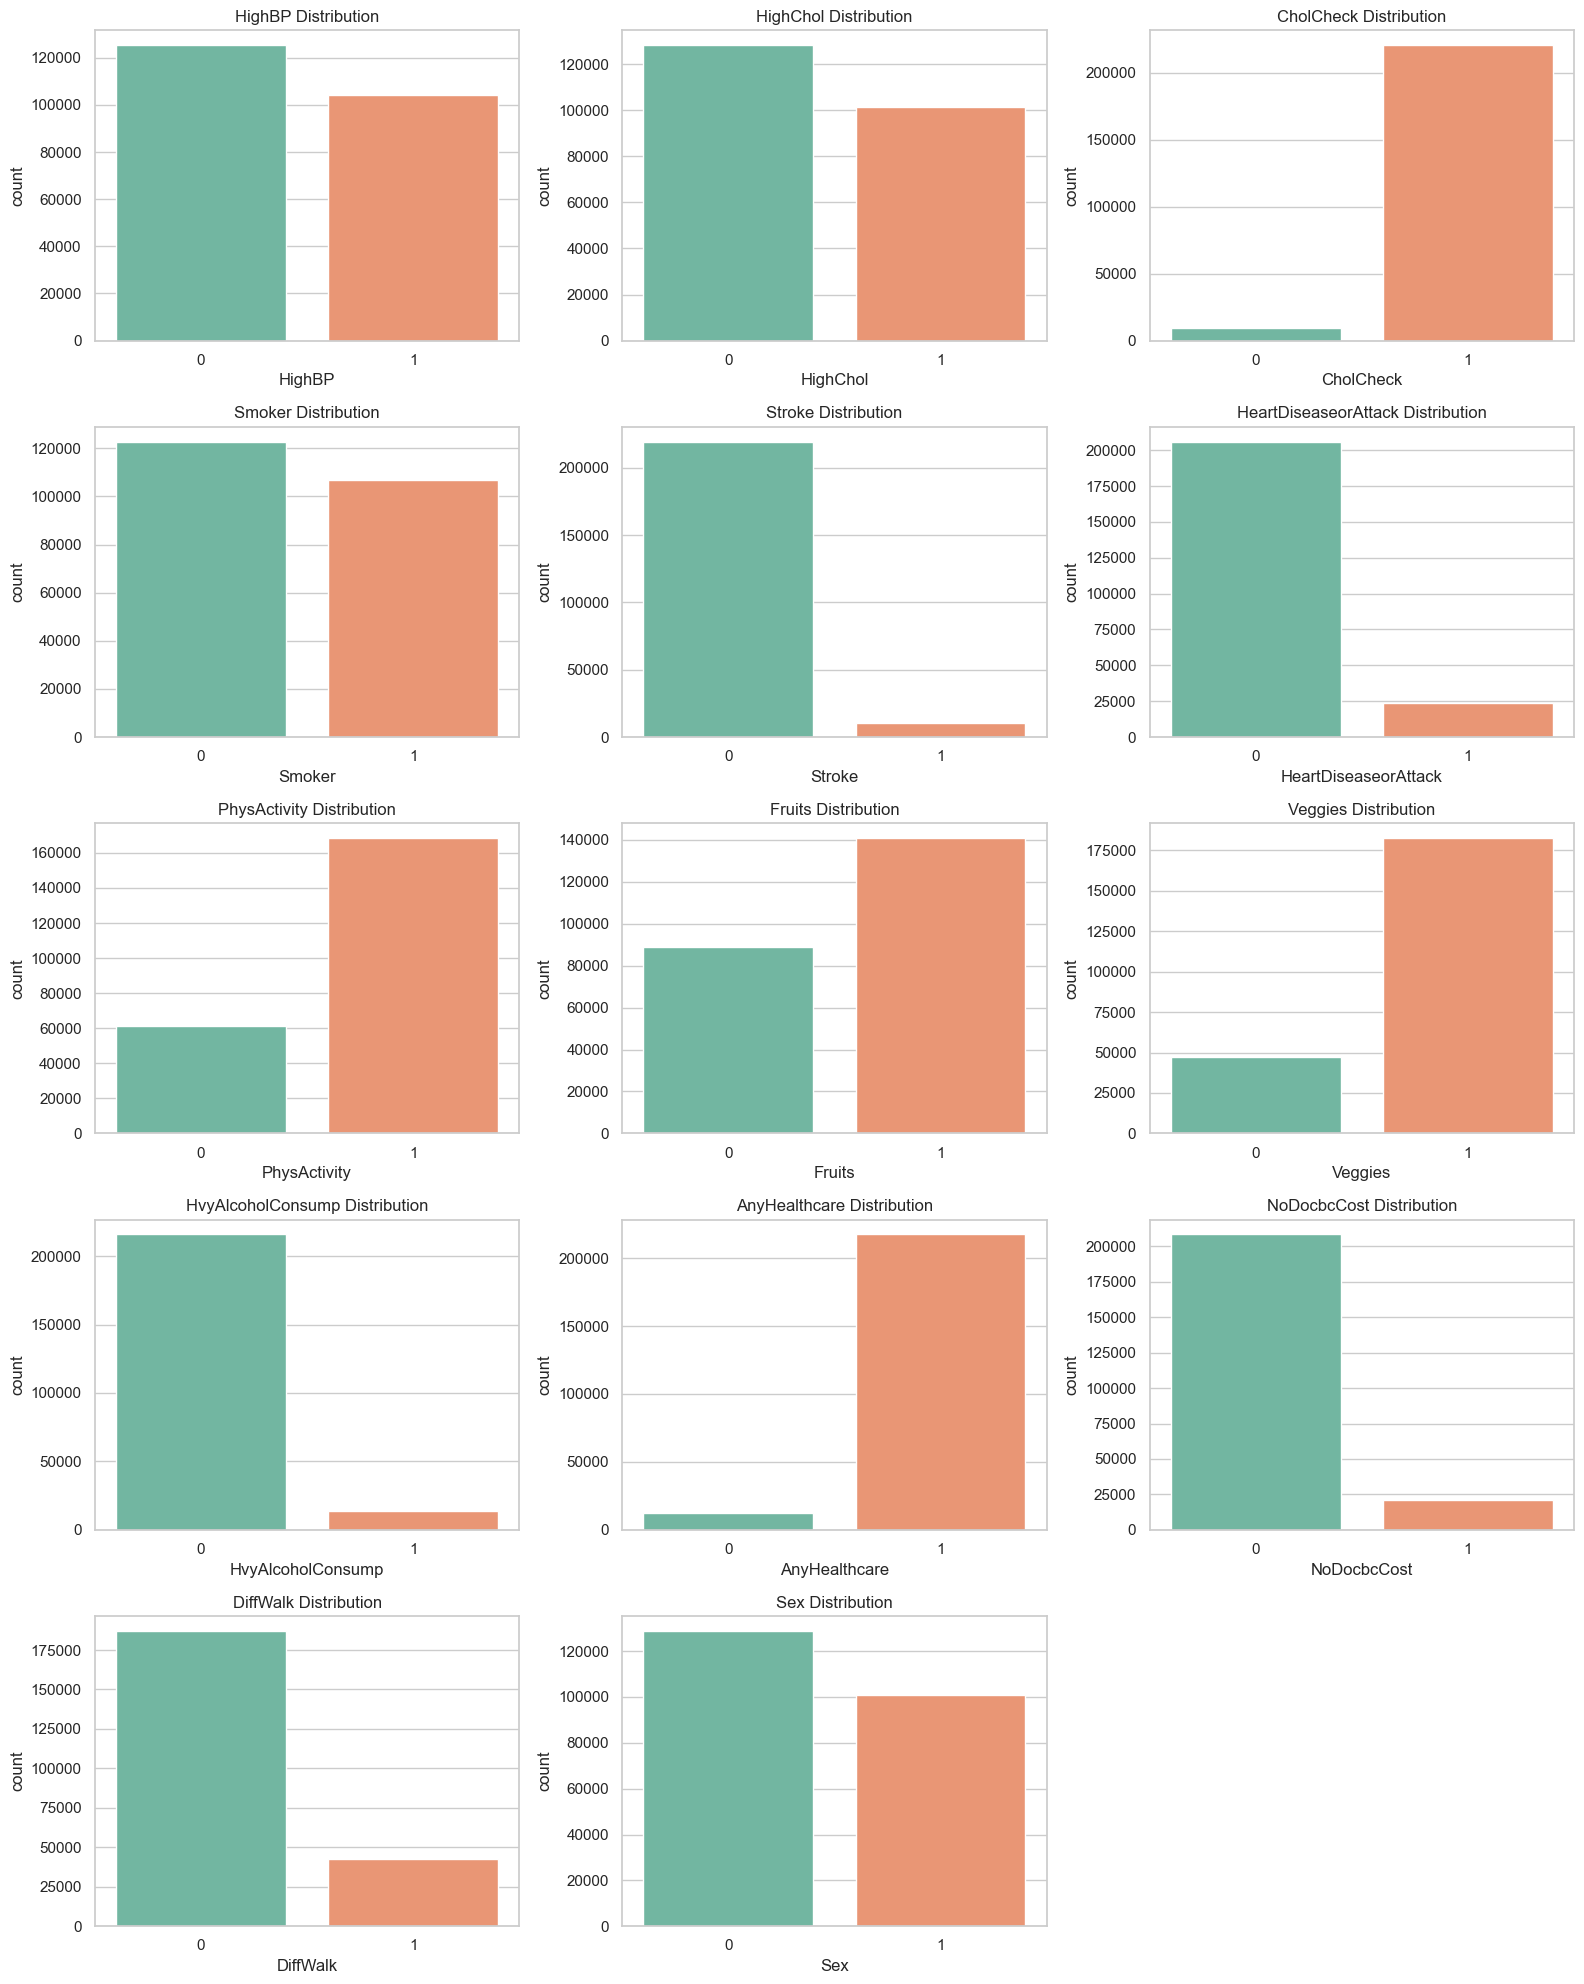

In [72]:
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
               'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
               'Fruits', 'Veggies', 'HvyAlcoholConsump',
               'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

plt.figure(figsize=(16, 20))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(5, 3, i)  # Adjust grid to fit all plots
    sns.countplot(data=df_copy, x=col, palette='Set2')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


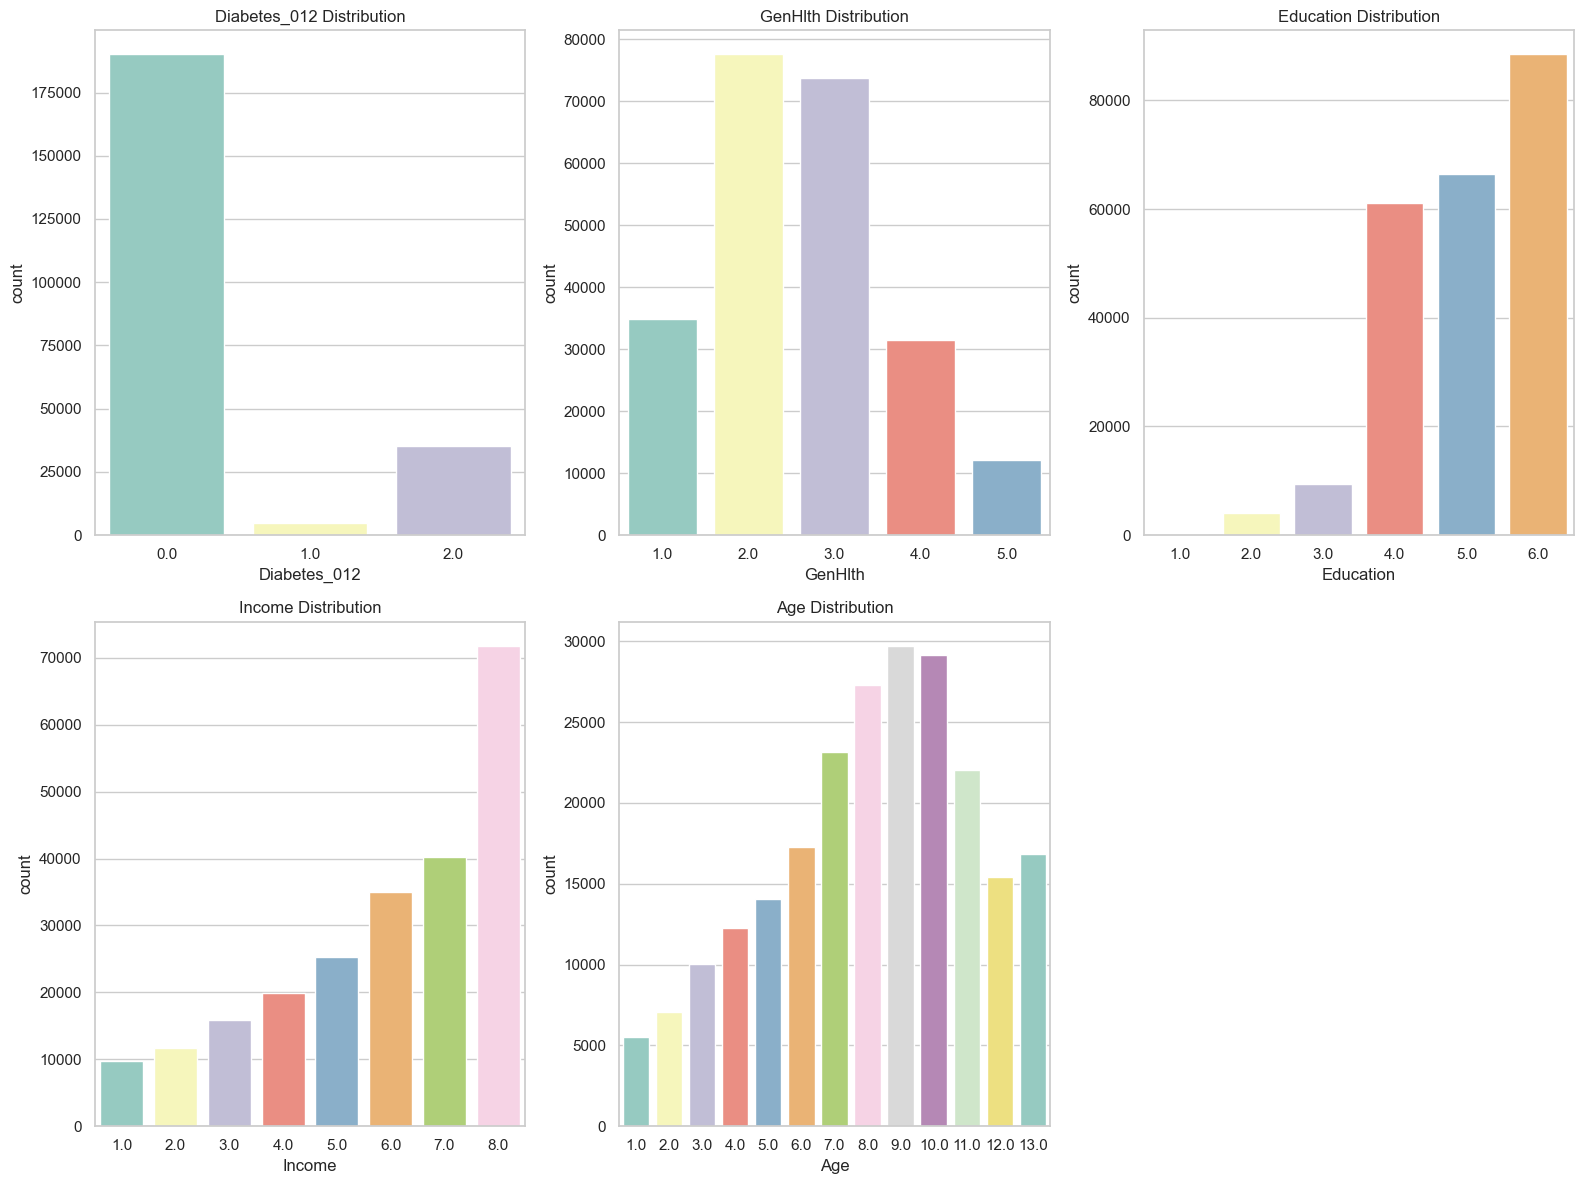

In [73]:
categorical_cols = ['Diabetes_012', 'GenHlth', 'Education', 'Income', 'Age']

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df_copy, x=col, palette='Set3')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


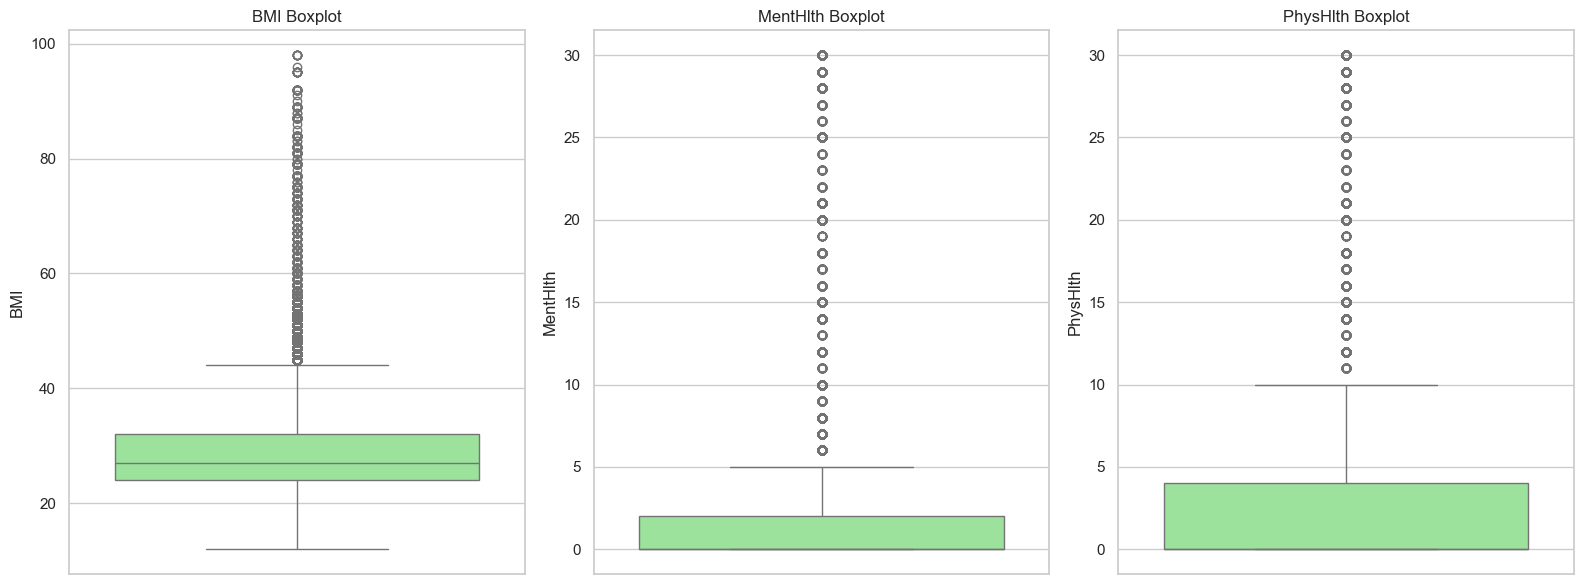

In [74]:
plt.figure(figsize=(16, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_copy[col], color='lightgreen')
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()


In [80]:
for col in ['BMI', 'MentHlth', 'PhysHlth']:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_copy[(df_copy[col] < Q1 - 1.5 * IQR) | (df_copy[col] > Q3 + 1.5 * IQR)]
    print(f"{col} outliers: {len(outliers)}")




BMI outliers: 5638
MentHlth outliers: 36163
PhysHlth outliers: 34347


BMI Statistics After Capping:
count    229781.000000
mean         28.629639
std           6.429856
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          60.000000
Name: BMI, dtype: float64
Number of BMI values > 60 before capping: 0
Number of BMI values > 60 after capping: 0

MentHlth Statistics After Capping:
count    229781.000000
mean          3.234610
std           6.815324
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          25.000000
Name: MentHlth, dtype: float64
Number of MentHlth values > 25 before capping: 0
Number of MentHlth values > 25 after capping: 0

PhysHlth Statistics After Capping:
count    229781.000000
mean          4.241621
std           7.866498
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max          25.000000
Name: PhysHlth, dtype: float64
Number of PhysHlth values > 25 before capping: 0
Number of PhysHlth values

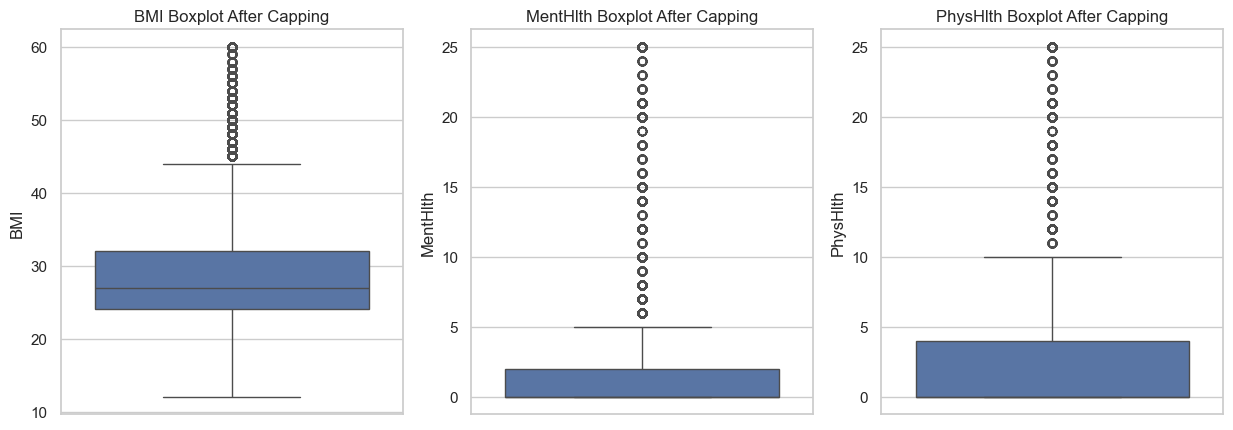

In [81]:

# --- Outlier Handling for BMI ---
# Option 1: Cap BMI at 60 (upper clinical limit)
df_copy['BMI'] = df_copy['BMI'].clip(upper=60)  # Caps values > 60 at 60


# Verify the change
print("BMI Statistics After Capping:")
print(df_copy['BMI'].describe())
print(f"Number of BMI values > 60 before capping: {len(df_copy[df_copy['BMI'] > 60])}")
print(f"Number of BMI values > 60 after capping: {len(df_copy[df_copy['BMI'] > 60])}")

# --- Outlier Handling for MentHlth and PhysHlth ---
# Cap at 25 (upper whisker based on boxplot, ~1.5*IQR above Q3)
for col in ['MentHlth', 'PhysHlth']:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR  # Approximately 25 based on your boxplot
    df_copy[col] = df_copy[col].clip(upper=25)  # Caps values > 25 at 25

    # Verify the change
    print(f"\n{col} Statistics After Capping:")
    print(df_copy[col].describe())
    print(f"Number of {col} values > 25 before capping: {len(df_copy[df_copy[col] > 25])}")
    print(f"Number of {col} values > 25 after capping: {len(df_copy[df_copy[col] > 25])}")

# Optional: Re-plot boxplots to confirm

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); sns.boxplot(data=df_copy, y='BMI'); plt.title('BMI Boxplot After Capping')
plt.subplot(1, 3, 2); sns.boxplot(data=df_copy, y='MentHlth'); plt.title('MentHlth Boxplot After Capping')
plt.subplot(1, 3, 3); sns.boxplot(data=df_copy, y='PhysHlth'); plt.title('PhysHlth Boxplot After Capping')
plt.show()

In [75]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway

#  Target variable
target = 'Diabetes_012'

# ---------------------------------------------
# 1️ Chi-Square Test for Categorical Predictors
# ---------------------------------------------
categorical_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income'
]

print(" Chi-Square Test Results & Interpretation:")
for col in categorical_cols:
    table = pd.crosstab(df_copy[col], df_copy[target])
    chi2, p, dof, ex = chi2_contingency(table)
    if p < 0.05:
        print(f"- {col}: p={p:.4f} → ✅ Significantly associated with Diabetes")
        print()
    else:
        print(f"- {col}: p={p:.4f} → ❌ No significant association with Diabetes")
        print()

# -------------------------------
# 2️ ANOVA for Numeric Predictors
# -------------------------------
numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']

print("\n ANOVA Results & Interpretation:")
for col in numeric_cols:
    groups = [df_copy[df_copy[target] == c][col] for c in df_copy[target].cat.categories]
    f_stat, p = f_oneway(*groups)
    if p < 0.05:
        print(f"- {col}: p={p:.4f} → ✅ Mean differs significantly across diabetes groups")
        print()
    else:
        print(f"- {col}: p={p:.4f} → ❌ No significant difference across diabetes groups")
        print()

# ----------------------------------------
# ✅ Summary of Use:
# - Chi-Square → categorical features vs target.
# - ANOVA → numeric features vs target.
# Output directly prints interpretation for each predictor.
# ----------------------------------------


 Chi-Square Test Results & Interpretation:
- HighBP: p=0.0000 → ✅ Significantly associated with Diabetes

- HighChol: p=0.0000 → ✅ Significantly associated with Diabetes

- CholCheck: p=0.0000 → ✅ Significantly associated with Diabetes

- Smoker: p=0.0000 → ✅ Significantly associated with Diabetes

- Stroke: p=0.0000 → ✅ Significantly associated with Diabetes

- HeartDiseaseorAttack: p=0.0000 → ✅ Significantly associated with Diabetes

- PhysActivity: p=0.0000 → ✅ Significantly associated with Diabetes

- Fruits: p=0.0000 → ✅ Significantly associated with Diabetes

- Veggies: p=0.0000 → ✅ Significantly associated with Diabetes

- HvyAlcoholConsump: p=0.0000 → ✅ Significantly associated with Diabetes

- AnyHealthcare: p=0.0000 → ✅ Significantly associated with Diabetes

- NoDocbcCost: p=0.0000 → ✅ Significantly associated with Diabetes

- DiffWalk: p=0.0000 → ✅ Significantly associated with Diabetes

- Sex: p=0.0000 → ✅ Significantly associated with Diabetes

- GenHlth: p=0.0000 → ✅ Sig

                   BMI  MentHlth  PhysHlth  Diabetes_012
BMI           1.000000  0.068653  0.102844      0.212027
MentHlth      0.068653  1.000000  0.340362      0.057698
PhysHlth      0.102844  0.340362  1.000000      0.160485
Diabetes_012  0.212027  0.057698  0.160485      1.000000


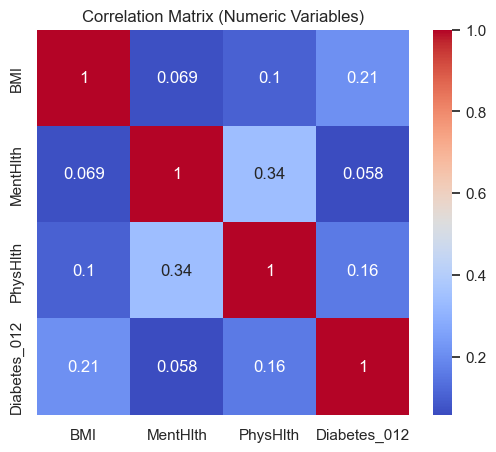

In [76]:
# Numeric correlation matrix
numeric_cols = ['BMI', 'MentHlth', 'PhysHlth']
corr_matrix = df_copy[numeric_cols + ['Diabetes_012']].corr()
print(corr_matrix)



plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Variables)")
plt.show()


In [77]:


def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
                    'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income']

cramers_results = {col: cramers_v(df_copy[col], df_copy['Diabetes_012']) for col in categorical_cols}
cramers_results = pd.Series(cramers_results).sort_values(ascending=False)
print(cramers_results)


HighBP                  0.262432
DiffWalk                0.210721
GenHlth                 0.205144
HighChol                0.204835
HeartDiseaseorAttack    0.170860
Age                     0.139753
Income                  0.105905
PhysActivity            0.103488
Stroke                  0.100389
Education               0.078801
CholCheck               0.076318
HvyAlcoholConsump       0.067166
Smoker                  0.046800
Veggies                 0.043583
Sex                     0.032607
NoDocbcCost             0.027975
Fruits                  0.025464
AnyHealthcare           0.025224
dtype: float64


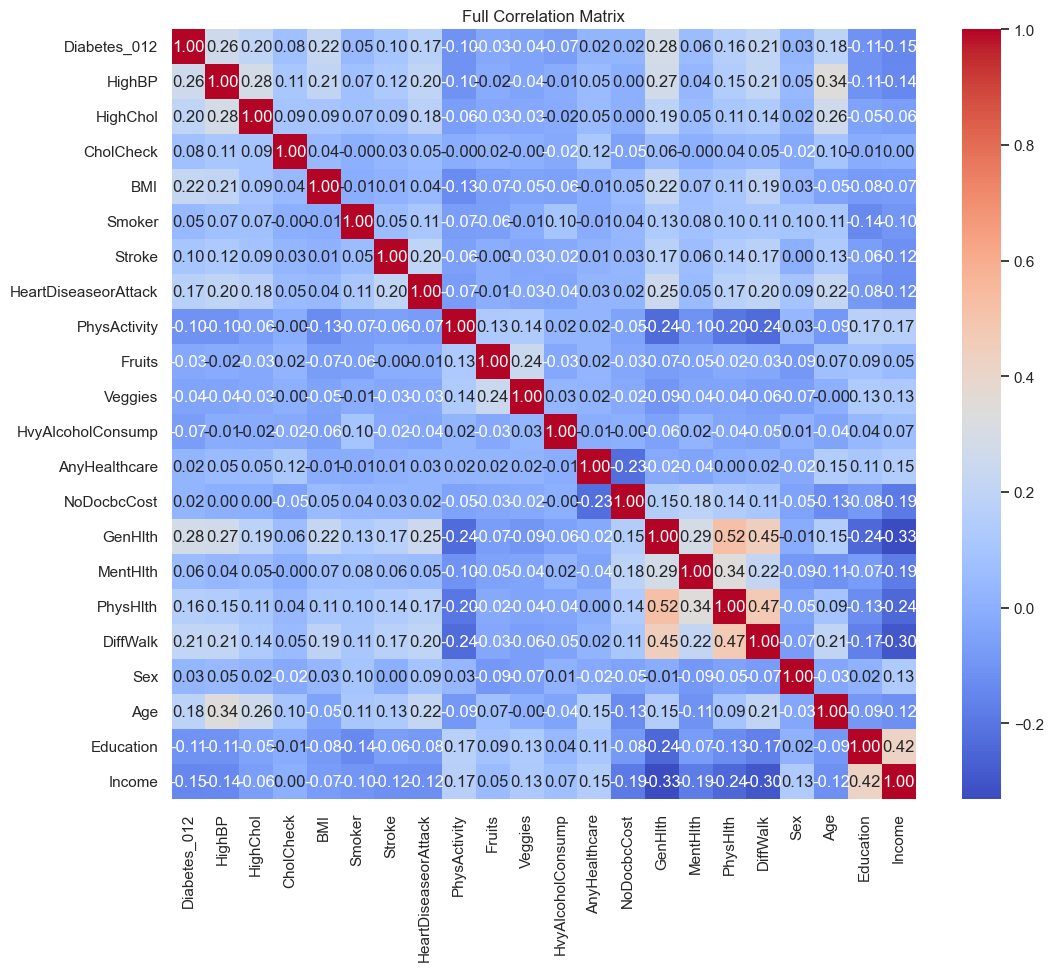

                 Feature        VIF
19             Education  27.157453
2              CholCheck  21.590969
11         AnyHealthcare  18.994731
3                    BMI  18.977022
20                Income  12.602491
13               GenHlth  11.085601
18                   Age   9.781869
9                Veggies   5.288099
7           PhysActivity   4.141078
8                 Fruits   2.828389
0                 HighBP   2.356196
15              PhysHlth   2.069479
1               HighChol   2.067606
4                 Smoker   1.985366
17                   Sex   1.907050
16              DiffWalk   1.854176
14              MentHlth   1.499943
6   HeartDiseaseorAttack   1.296711
12           NoDocbcCost   1.220340
5                 Stroke   1.128083
10     HvyAlcoholConsump   1.091522


In [84]:
# Full correlation matrix
full_corr = df_copy.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Full Correlation Matrix")
plt.show()

# Compute VIF for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df_copy.drop('Diabetes_012', axis=1)  # Features only
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

